### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read Dataset

In [2]:
data = pd.read_csv("weather_classification_data.csv")
data.head(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


## Data Description

In [3]:
data.shape

(13200, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


#### Notice that the range of the data off so it needs **NORMALIZATION / STANDARIZATION**

In [5]:
data.describe().round(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00
mean,19.13,68.71,9.83,53.64,1005.83,4.01,5.46
std,17.39,20.19,6.91,31.95,37.20,3.86,3.37
min,-25.00,20.00,0.00,0.00,800.12,0.00,0.00
25%,4.00,57.00,5.00,19.00,994.80,1.00,3.00
50%,21.00,70.00,9.00,58.00,1007.65,3.00,5.00
75%,31.00,84.00,13.50,82.00,1016.77,7.00,7.50
max,109.00,109.00,48.50,109.00,1199.21,14.00,20.00


# Data Preprocessing

## Data Cleaning

#### Check **Nulls**

In [6]:
data.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

#### Check **Duplicates**

In [7]:
data.duplicated().sum()

0

#### Check Outliers for numeric data and plot them

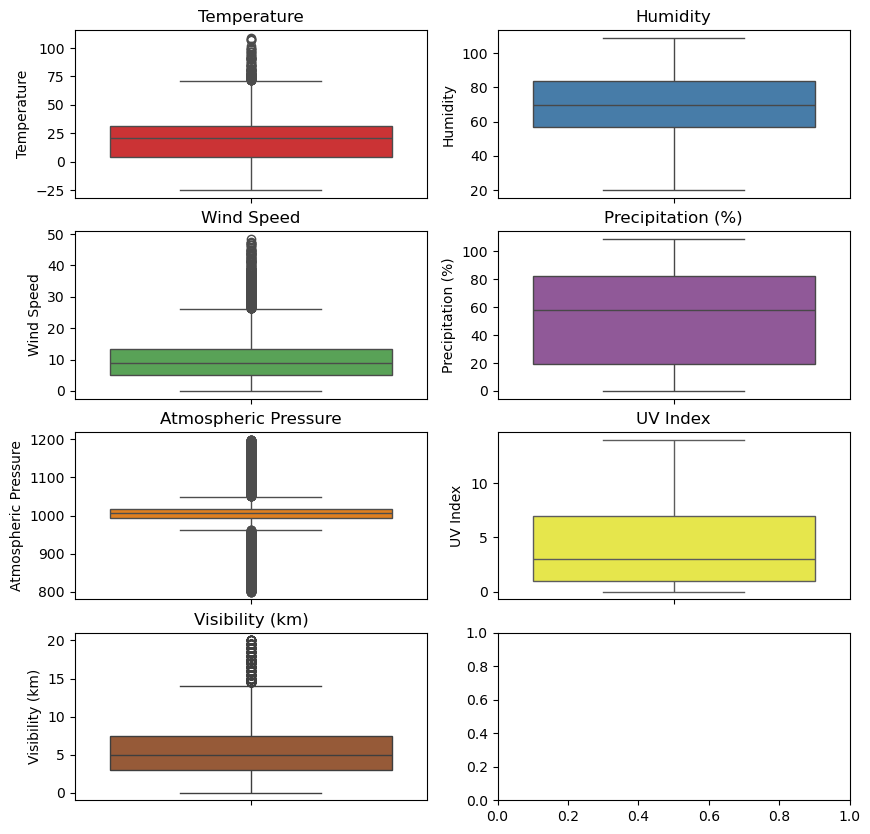

In [8]:
# divide the columns into 2 sections :

# 1- columns that has numerical values so could handle the outliers 
numeric_columns = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

# 2- columns that has catigorical valuees for encoding
catagorial_comlumns = ['Cloud Cover','Season','Location','Weather Type']

# calc the number of rows needed for the figure
rows_n = (len(numeric_columns) // 2) +1

# figure for box plots of each column to calculate outlier
fig, axes = plt.subplots(nrows=rows_n, ncols=2 , figsize=(10, 10))
colors = sns.color_palette("Set1", len(numeric_columns))
axes = axes.ravel()
for i, column in enumerate(numeric_columns):
    sns.boxplot(data=data, y=column, ax=axes[i] , color=colors[i])
    axes[i].set_title(column)

plt.show()

In [9]:
# Calculate Q1, Q3 and IQR
# Filter out outliers based on IQR
for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.3 * IQR
    upper_bound = Q3 + 1.3 * IQR
    
    # data[col] = np.clip(data[col], lower_bound, upper_bound)
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

In [10]:
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10624 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           10624 non-null  float64
 1   Humidity              10624 non-null  int64  
 2   Wind Speed            10624 non-null  float64
 3   Precipitation (%)     10624 non-null  float64
 4   Cloud Cover           10624 non-null  object 
 5   Atmospheric Pressure  10624 non-null  float64
 6   UV Index              10624 non-null  int64  
 7   Season                10624 non-null  object 
 8   Visibility (km)       10624 non-null  float64
 9   Location              10624 non-null  object 
 10  Weather Type          10624 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 996.0+ KB


In [12]:
data.describe().round(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00
mean,18.03,70.54,9.24,52.65,1005.51,2.94,4.98
std,15.33,17.87,5.46,31.08,12.63,2.90,2.53
min,-24.00,24.00,0.00,0.00,966.42,0.00,0.00
25%,4.00,60.00,5.00,20.00,995.37,1.00,3.00
50%,21.00,71.00,8.75,57.00,1006.68,2.00,4.50
75%,29.00,84.00,13.50,80.00,1015.51,4.00,7.00
max,66.00,109.00,24.50,109.00,1045.09,10.00,12.00


# Exploratory Data Analysis (EDA)

### Plot for the distribution of data in the numeric columns to give insight of the data 

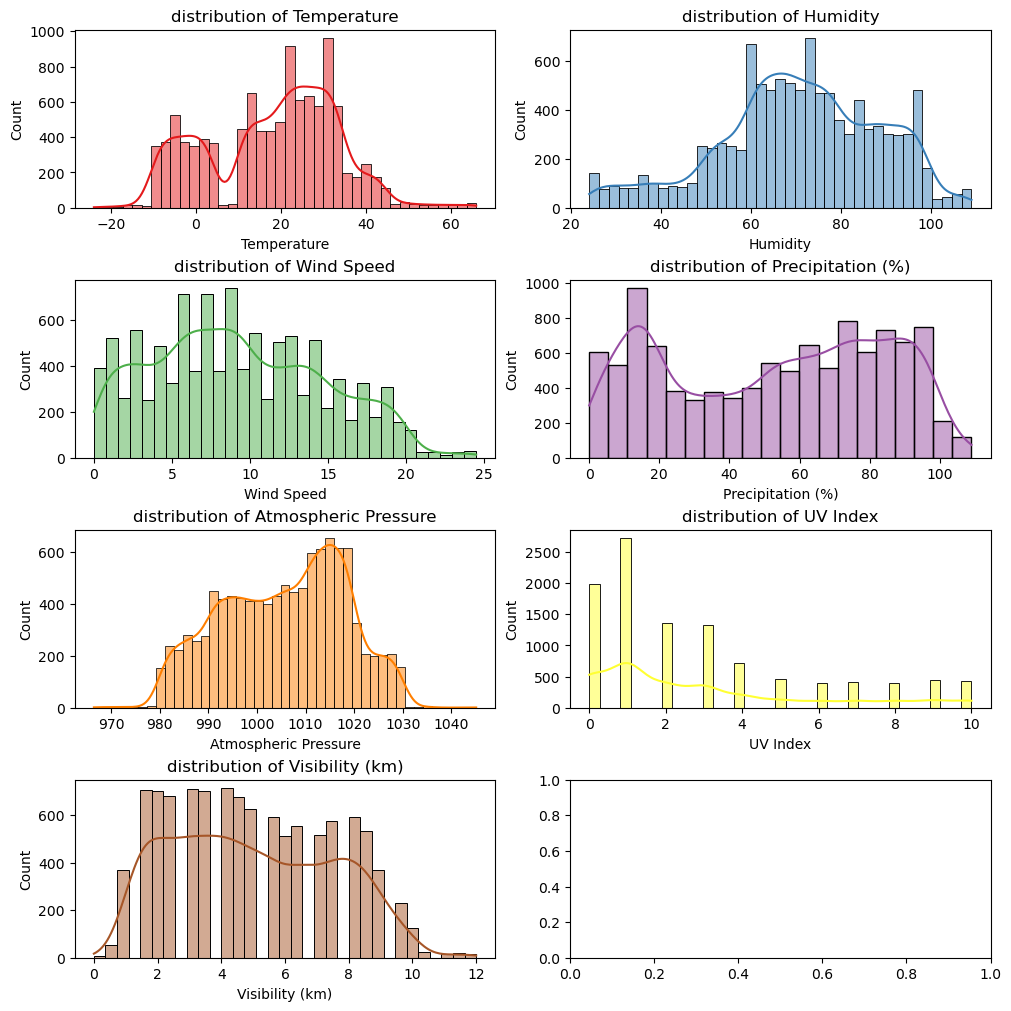

In [13]:
rows_n = (len(numeric_columns) // 2) +1
fig, axes = plt.subplots(nrows=rows_n, ncols=2 , figsize=(10, 10), constrained_layout=True)
colors = sns.color_palette("Set1", len(numeric_columns))
axes = axes.ravel()
for i, column in enumerate(numeric_columns):
    sns.histplot(data=data, x=column, ax=axes[i] , color=colors[i],kde=True)
    axes[i].set_title(f'distribution of {column}')


plt.show()

### **Boxplot** of the columns after removing outliers 

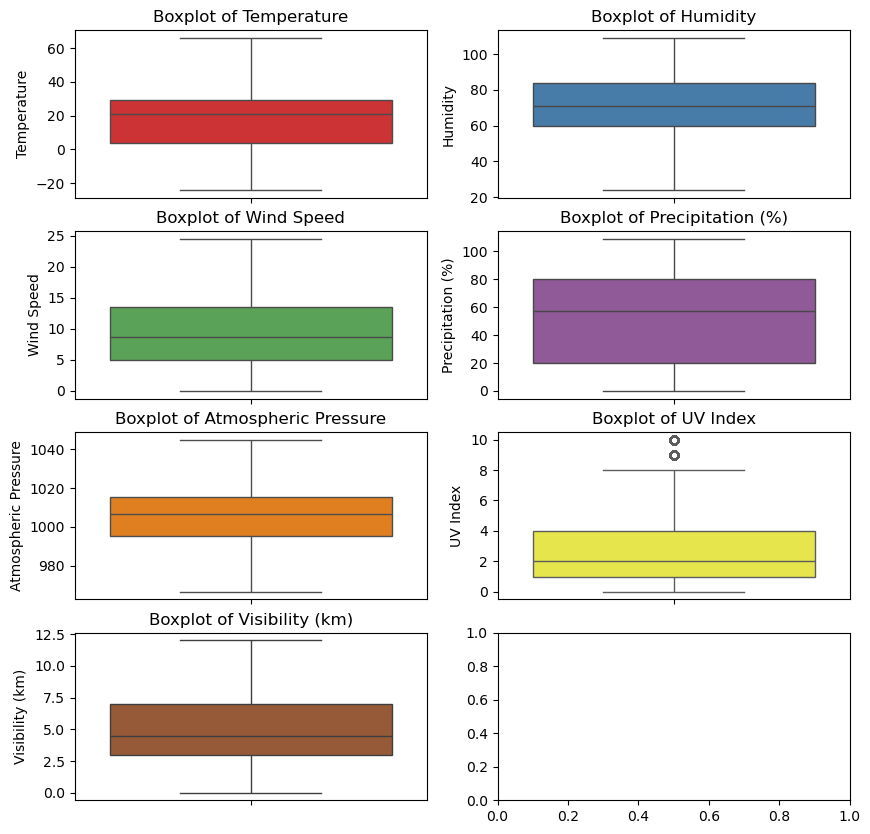

In [14]:
fig, axes = plt.subplots(nrows=rows_n, ncols=2 , figsize=(10, 10))
colors = sns.color_palette("Set1", len(numeric_columns))
axes = axes.ravel()
for i, column in enumerate(numeric_columns):
    sns.boxplot(data=data, y=column, ax=axes[i] , color=colors[i])
    axes[i].set_title(f'Boxplot of {column}')


plt.show()

### Bar plot for correlation between each features of the data 

In [15]:
# sns.pairplot(data, hue='Weather Type',palette='Set1')

### Distribution of Weather Type

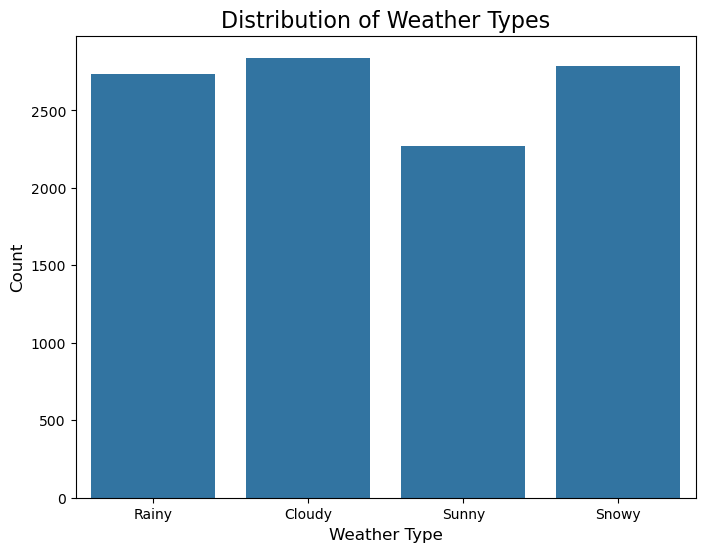

In [16]:
# Bar chart for Weather Type
plt.figure(figsize=(8, 6))
sns.countplot(x='Weather Type', data=data)
plt.title('Distribution of Weather Types', fontsize=16)
plt.xlabel('Weather Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Seasonal Trends

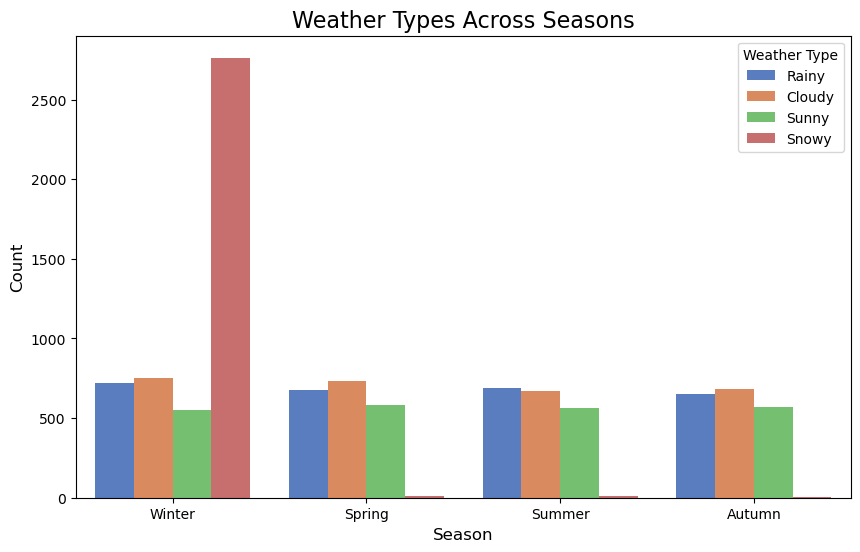

In [17]:
# Count of weather types across seasons
plt.figure(figsize=(10, 6))
sns.countplot(x='Season', hue='Weather Type', data=data, palette='muted')
plt.title('Weather Types Across Seasons', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Weather Type')
plt.show()

### Location-Based Weather Analysis

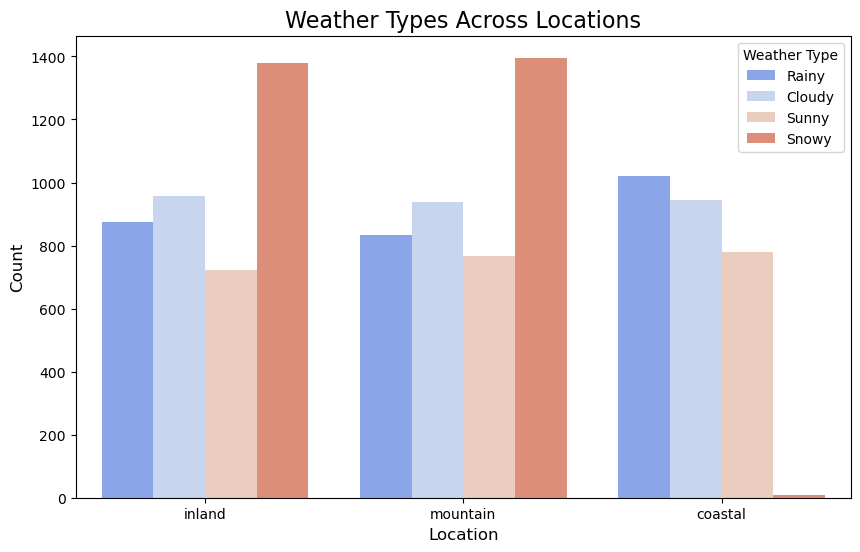

In [18]:
# Grouped bar chart for weather types by location
plt.figure(figsize=(10, 6))
sns.countplot(x='Location', hue='Weather Type', data=data, palette='coolwarm')
plt.title('Weather Types Across Locations', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Weather Type')
plt.show()

In [19]:
data_LE = data.copy()

## Label Encoding.

In [20]:
##display the number of catagorial in each feature 
for column in catagorial_comlumns :
    print(data_LE[column].value_counts())
    print ('----------------------------------')

Cloud Cover
overcast         5284
partly cloudy    3714
clear            1594
cloudy             32
Name: count, dtype: int64
----------------------------------
Season
Winter    4786
Spring    2001
Summer    1925
Autumn    1912
Name: count, dtype: int64
----------------------------------
Location
inland      3935
mountain    3935
coastal     2754
Name: count, dtype: int64
----------------------------------
Weather Type
Cloudy    2840
Snowy     2784
Rainy     2733
Sunny     2267
Name: count, dtype: int64
----------------------------------


In [21]:
## label encode these features
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()
for col in catagorial_comlumns:
    data_LE[col] = LE.fit_transform(data_LE[col])

In [22]:
## display them
for column in catagorial_comlumns :
    print(data_LE[column].value_counts())
    print ('----------------------------------')

Cloud Cover
2    5284
3    3714
0    1594
1      32
Name: count, dtype: int64
----------------------------------
Season
3    4786
1    2001
2    1925
0    1912
Name: count, dtype: int64
----------------------------------
Location
1    3935
2    3935
0    2754
Name: count, dtype: int64
----------------------------------
Weather Type
0    2840
2    2784
1    2733
3    2267
Name: count, dtype: int64
----------------------------------


# Preprocessed Data

In [23]:
data_LE.head(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1
5,32.0,55,3.5,26.0,2,1010.03,2,2,5.0,1,0
6,-2.0,97,8.0,86.0,2,990.87,1,3,4.0,1,2
7,3.0,85,6.0,96.0,3,984.46,1,3,3.5,1,2
8,3.0,83,6.0,66.0,2,999.44,0,3,1.0,2,2
9,28.0,74,8.5,107.0,0,1012.13,8,3,7.5,0,3


In [24]:
data_LE.shape

(10624, 11)

In [25]:
data_LE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10624 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           10624 non-null  float64
 1   Humidity              10624 non-null  int64  
 2   Wind Speed            10624 non-null  float64
 3   Precipitation (%)     10624 non-null  float64
 4   Cloud Cover           10624 non-null  int32  
 5   Atmospheric Pressure  10624 non-null  float64
 6   UV Index              10624 non-null  int64  
 7   Season                10624 non-null  int32  
 8   Visibility (km)       10624 non-null  float64
 9   Location              10624 non-null  int32  
 10  Weather Type          10624 non-null  int32  
dtypes: float64(5), int32(4), int64(2)
memory usage: 830.0 KB


In [26]:
data_LE.describe().round(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00,10624.00
mean,18.03,70.54,9.24,52.65,2.05,1005.51,2.94,1.90,4.98,1.11,1.42
std,15.33,17.87,5.46,31.08,0.98,12.63,2.90,1.16,2.53,0.79,1.10
min,-24.00,24.00,0.00,0.00,0.00,966.42,0.00,0.00,0.00,0.00,0.00
25%,4.00,60.00,5.00,20.00,2.00,995.37,1.00,1.00,3.00,0.00,0.00
50%,21.00,71.00,8.75,57.00,2.00,1006.68,2.00,2.00,4.50,1.00,1.00
75%,29.00,84.00,13.50,80.00,3.00,1015.51,4.00,3.00,7.00,2.00,2.00
max,66.00,109.00,24.50,109.00,3.00,1045.09,10.00,3.00,12.00,2.00,3.00


In [27]:
data_LE.corr()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
Temperature,1.000000,-0.340197,-0.121214,-0.425414,-0.224043,0.692491,0.531162,-0.466240,0.477159,-0.238836,-0.040369
Humidity,-0.340197,1.000000,0.369022,0.686453,0.291177,-0.459487,-0.482663,0.188798,-0.529471,0.076978,-0.225474
Wind Speed,-0.121214,0.369022,1.000000,0.427730,0.176575,-0.235312,-0.267809,0.046497,-0.353477,-0.004806,-0.157927
Precipitation (%),-0.425414,0.686453,0.427730,1.000000,0.271152,-0.558504,-0.535468,0.246408,-0.683627,0.105007,-0.107582
Cloud Cover,-0.224043,0.291177,0.176575,0.271152,1.000000,-0.290812,-0.440987,0.058290,-0.216391,0.023726,-0.561506
Atmospheric Pressure,0.692491,-0.459487,-0.235312,-0.558504,-0.290812,1.000000,0.582000,-0.421203,0.568159,-0.195811,0.064624
UV Index,0.531162,-0.482663,-0.267809,-0.535468,-0.440987,0.582000,1.000000,-0.257861,0.510160,-0.121709,0.413428
Season,-0.466240,0.188798,0.046497,0.246408,0.058290,-0.421203,-0.257861,1.000000,-0.274425,0.172717,0.162093
Visibility (km),0.477159,-0.529471,-0.353477,-0.683627,-0.216391,0.568159,0.510160,-0.274425,1.000000,-0.111106,-0.003938
Location,-0.238836,0.076978,-0.004806,0.105007,0.023726,-0.195811,-0.121709,0.172717,-0.111106,1.000000,0.095402


<Axes: >

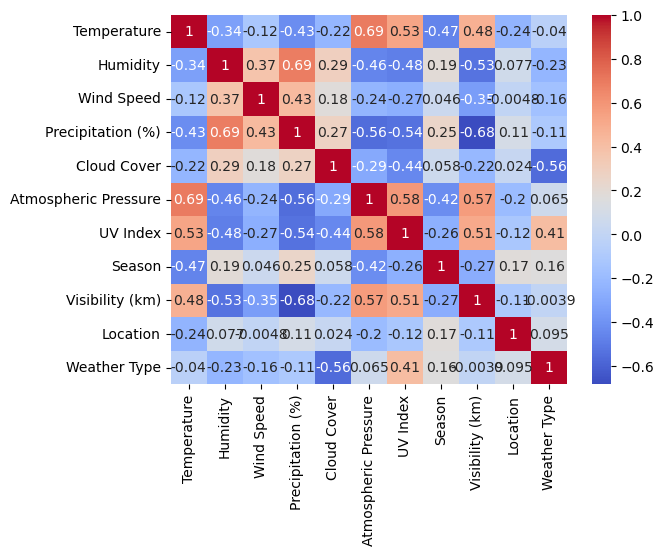

In [28]:
## a heat map for data correlation
sns.heatmap(data=data_LE.corr(), annot=True, cmap='coolwarm')

# Machine Learning

#### By practicing **Classification Algorithms** To create a **machine learning model** that predicts the **Weather Type** based on the various weather-related features

In [29]:
## coping the data for each model we would use
knn_data = data_LE.copy() 
Naive_bayse_data = data_LE.copy()  
SVM_data = data_LE.copy()  
decision_tree_data = data_LE.copy() 

## Model Building
#### develop predictive models using four different machine learning algorithms: K-Nearest Neighbors (KNN), Decision Tree, Naive Bayes, and Support Vector Machine (SVM)

# 1. K-Nearest Neighbors (KNN)

## Features Selection
#### Preparing the data for the model

In [30]:
# Splitting features and target
knn_X = knn_data.drop('Weather Type', axis=1)
knn_y = knn_data['Weather Type']

knn_X.head() , knn_y.head()

(   Temperature  Humidity  Wind Speed  Precipitation (%)  Cloud Cover  \
 0         14.0        73         9.5               82.0            3   
 1         39.0        96         8.5               71.0            3   
 2         30.0        64         7.0               16.0            0   
 3         38.0        83         1.5               82.0            0   
 4         27.0        74        17.0               66.0            2   
 
    Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  
 0               1010.82         2       3              3.5         1  
 1               1011.43         7       1             10.0         1  
 2               1018.72         5       1              5.5         2  
 3               1026.25         7       1              1.0         0  
 4                990.67         1       3              2.5         2  ,
 0    1
 1    0
 2    3
 3    3
 4    1
 Name: Weather Type, dtype: int32)

In [31]:
knn_X.shape , knn_y.shape

((10624, 10), (10624,))

## Data Splitting
#### Split the data into 80% training and 20% testing

In [32]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(knn_X, knn_y, test_size=0.2, random_state=42)

### Standardization

In [33]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Validation (Tuning Hyperparameters)
#### Starting by knowing what the **Best K** is so we put range from **1 to 20** and loop through it and know what is the best

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score # for Evaluation

k_values = range(1, 21)
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    knn_accuracies.append(accuracy_score(y_test, y_pred_knn))

In [35]:
# Optimal k
best_k = k_values[np.argmax(knn_accuracies)]
print("Best k for KNN:", best_k)

Best k for KNN: 3


#### After configure what is the **Best K** we need to know what is the **Best Distance** so we use **elbow method**

In [36]:
# list for each metric distance
distance_metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'cosine', 'jaccard']

#list for store the accuracy of each metric distance
accuracy_by_metric =[]
# Evaluate each metric
for metric in distance_metrics:
        model = KNeighborsClassifier(n_neighbors=3, metric=metric)
        
        # fit the model
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        # Calculate accuracy and append it into the list
        acc = accuracy_score(y_test, y_pred)
        accuracy_by_metric.append(acc)

accuracy_by_metric

[0.9727058823529412,
 0.971764705882353,
 0.9675294117647059,
 0.9727058823529412,
 0.9703529411764706,
 0.2625882352941176]

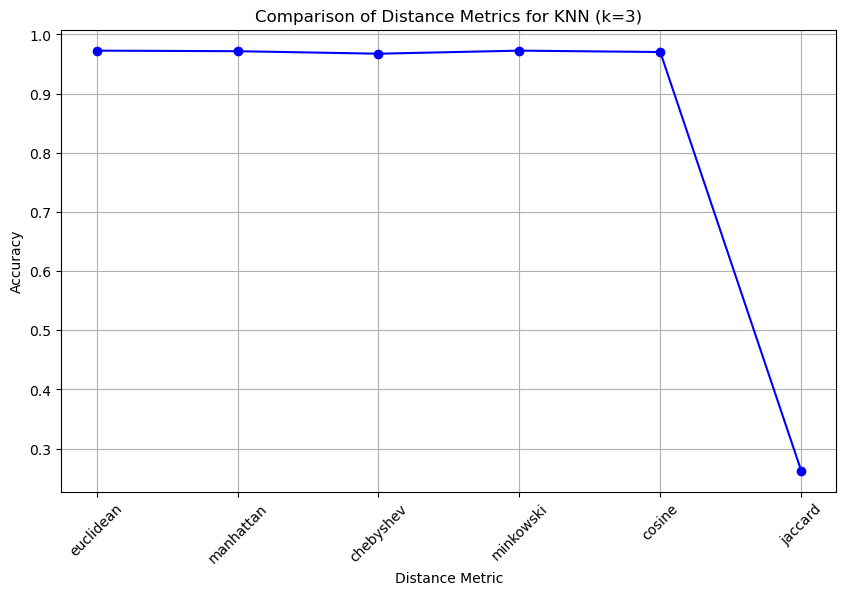

In [37]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(distance_metrics, accuracy_by_metric, marker='o', linestyle='-', color='blue', label='Accuracy')
plt.title('Comparison of Distance Metrics for KNN (k=3)')
plt.xlabel('Distance Metric')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [38]:
# Print accuracies for each metric
for index in range(len(accuracy_by_metric)):
    print(f"Accuracy for {distance_metrics[index]}: {accuracy_by_metric[index]}")

Accuracy for euclidean: 0.9727058823529412
Accuracy for manhattan: 0.971764705882353
Accuracy for chebyshev: 0.9675294117647059
Accuracy for minkowski: 0.9727058823529412
Accuracy for cosine: 0.9703529411764706
Accuracy for jaccard: 0.2625882352941176


## Model Training
#### Train the data using **K Neighbors Classifier Model**

In [39]:
## the best K=3 and the distance close to each others except jaccard so we use the euclidean distance
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

### Model Testing
#### Test the model by **Predicting y** and compare it with **Testing y**

In [40]:
# predict the knn values
y_pred_knn = knn.predict(X_test)
y_pred_knn

array([0, 2, 2, ..., 0, 1, 3])

In [41]:
y_test

1929     0
3292     2
2021     2
11972    2
11297    1
        ..
6477     2
11656    2
1504     0
8159     1
12793    3
Name: Weather Type, Length: 2125, dtype: int32

## Model Evaluation

#### ConFusion matrix for **KNN Model**

In [42]:
from sklearn.metrics import confusion_matrix

In [43]:
confusion_matrix(y_test,y_pred_knn)

array([[558,  15,   2,   3],
       [ 13, 534,   3,   1],
       [  2,   2, 552,   2],
       [ 10,   5,   0, 423]], dtype=int64)

#### Classification Report

In [44]:
from sklearn.metrics import classification_report

print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       578
           1       0.96      0.97      0.96       551
           2       0.99      0.99      0.99       558
           3       0.99      0.97      0.98       438

    accuracy                           0.97      2125
   macro avg       0.97      0.97      0.97      2125
weighted avg       0.97      0.97      0.97      2125



#### **MSE** & **R^2** of The Model

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate the model using MSE, and R² score
mse = mean_squared_error(y_test, y_pred_knn)
r2 = r2_score(y_test, y_pred_knn)

print(f'Mean Squared Error of (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Squared Error of (MSE): 0.0903529411764706
R² Score: 0.9245040582769457


# 2. Naive Bayes

## Features Selection

In [46]:
# Splitting features and target
Naive_bayse_X = Naive_bayse_data.drop('Weather Type', axis=1)
Naive_bayse_y = knn_data['Weather Type']

## Data Splitting

In [47]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(Naive_bayse_X, Naive_bayse_y, test_size=0.2, random_state=42)

### Standardization

In [48]:
# Feature scaling
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training
#### Train the data using **Gauss Naive Bayse Model**

In [49]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [50]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

### Model Testing

In [51]:
y_pred_nb = nb.predict(X_test)
y_pred_nb

array([0, 2, 2, ..., 0, 1, 3])

In [52]:
y_test

1929     0
3292     2
2021     2
11972    2
11297    1
        ..
6477     2
11656    2
1504     0
8159     1
12793    3
Name: Weather Type, Length: 2125, dtype: int32

## Model Evaluation
#### Confusion Matrix for **Naive Bayse Model**

In [53]:
confusion_matrix(y_test,y_pred_nb)

array([[546,  23,   0,   9],
       [  6, 538,   3,   4],
       [  1,   2, 552,   3],
       [  8,  14,   0, 416]], dtype=int64)

#### Classification Report

In [54]:
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96       578
           1       0.93      0.98      0.95       551
           2       0.99      0.99      0.99       558
           3       0.96      0.95      0.96       438

    accuracy                           0.97      2125
   macro avg       0.97      0.97      0.97      2125
weighted avg       0.97      0.97      0.97      2125



#### **MSE** & **R^2** of The Model

In [55]:
mse = mean_squared_error(y_test, y_pred_nb)
r2 = r2_score(y_test, y_pred_nb)

print(f'Mean Squared Error of (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Squared Error of (MSE): 0.1251764705882353
R² Score: 0.8954066640711853


# 3. Support Vector Machine (SVM)

## Features Selection

In [56]:
# Splitting features and target
svm_X = SVM_data.drop('Weather Type', axis=1)
svm_y = SVM_data['Weather Type']

## Data Splitting

In [57]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(svm_X, svm_y, test_size=0.2, random_state=42)

### Standardization

In [58]:
# Feature scaling
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Validation (Tuning Hyperparameters)
### Testing the best parameters for the model:
---

#### **C** -> For drawing the decison boundary if too low it would mix the items and too high would cause overfiting

#### **Kernal** -> is the mathmetical function for it

#### **decision_function_shape** -> for if you want to train the classifier for each class or for a pair of classes 

#### **Gamma** -> For be able to divide the data in the first place

In [59]:
from sklearn.svm import SVC

In [60]:
from sklearn.model_selection import GridSearchCV

In [59]:
from sklearn.model_selection import GridSearchCV

## tried use precomputed as kernal but it needs square kernal matrix
param_grid = {'C': [0.1,0.5,0.75, 1,5, 10],
              'kernel': ['linear', 'rbf','poly','sigmoid'],
              'decision_function_shape':['ovo', 'ovr'],
              'gamma': [0.1,0.5,2,7,5,3,1,10]}

## put the cross validation K = 5 and score by accuracy
# grid_svm = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
# grid_svm.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 0.5, 0.75, 1, 5, 10],
                         'decision_function_shape': ['ovo', 'ovr'],
                         'gamma': [0.1, 0.5, 2, 7, 5, 3, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='accuracy')

### **The Best Params** 
#### Regualarization = 10 , Shape = ONE OVER ONE , gamma = 0.1 and Function: 'Radial Basis Function'

In [60]:
print("Best SVM Parameters:", grid_svm.best_params_)

Best SVM Parameters: {'C': 10, 'decision_function_shape': 'ovo', 'gamma': 0.1, 'kernel': 'rbf'}


## Model Training
#### Apply Best Model

In [168]:
# svm_classifier = grid_svm.best_estimator_

In [61]:
# Create an SVM classifier with the specified parameters
svm_classifier = SVC(
    C=10, 
    decision_function_shape='ovo', 
    gamma=0.1, 
    kernel='rbf'
)

# Fit the classifier to your training data (X_train and y_train)
svm_classifier.fit(X_train, y_train)

SVC(C=10, decision_function_shape='ovo', gamma=0.1)

### Model Testing

In [62]:
y_pred_svm = svm_classifier.predict(X_test)
y_pred_svm

array([0, 2, 2, ..., 0, 1, 3])

In [63]:
y_test

1929     0
3292     2
2021     2
11972    2
11297    1
        ..
6477     2
11656    2
1504     0
8159     1
12793    3
Name: Weather Type, Length: 2125, dtype: int32

## Model Evaluation

#### Confusion Matrix for **SVM Model**

In [64]:
confusion_matrix(y_test,y_pred_svm)

array([[558,  12,   4,   4],
       [ 12, 538,   0,   1],
       [  2,   0, 553,   3],
       [  7,   2,   0, 429]], dtype=int64)

#### Classification Report

In [65]:
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       578
           1       0.97      0.98      0.98       551
           2       0.99      0.99      0.99       558
           3       0.98      0.98      0.98       438

    accuracy                           0.98      2125
   macro avg       0.98      0.98      0.98      2125
weighted avg       0.98      0.98      0.98      2125



#### **MSE** & **R^2** of The Model

In [66]:
mse = mean_squared_error(y_test, y_pred_svm)
r2 = r2_score(y_test, y_pred_svm)

print(f'Mean Squared Error of (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Squared Error of (MSE): 0.07623529411764705
R² Score: 0.936300299171173


# Decision Tree

## Features Selection

In [67]:
# Splitting features and target
decision_tree_X = decision_tree_data.drop('Weather Type', axis=1)
decision_tree_y = decision_tree_data['Weather Type']

## Data Splitting

In [68]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(decision_tree_X, decision_tree_y, test_size=0.2, random_state=42)

In [69]:
### Standardization

In [70]:
# Feature scaling
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Validation (Tuning Hyperparameters)
### Test the Parameters
---
#### max_depth ->imits how deep the tree can grow, which helps control overfitting so it has the number of all the features 

#### min_samples_split -> Minimum samples for spliting an internal node. Higher values make the tree less complex

#### criterion -> the function we use in decision tree 

#### splitter -> stratigy used for spliting nodes 

#### max_features -> number of features considred for the split 

#### min_samples_leaf ->Minimum number of samples required to be at a leaf node. Larger values prevent small, isolated splits

#### min_weight_fraction_leaf -> Controls the size of leaf nodes based on weights.

In [71]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [72]:
param_grid_dt = {
    'max_depth': range(1, 11),
    'min_samples_split': range(2, 11),
    'criterion': ['gini', 'entropy'],
    'splitter':['best', 'random'],
    'max_features': [None, 'sqrt', 'log2', 2, 5, 7],
    'min_samples_leaf': [1, 3, 5, 7],
    'min_weight_fraction_leaf': [0.1, 0.2, 0.3, 0.4]}

## grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 11),
                         'max_features': [None, 'sqrt', 'log2', 2, 5, 7],
                         'min_samples_leaf': [1, 3, 5, 7],
                         'min_samples_split': range(2, 11),
                         'min_weight_fraction_leaf': [0.1, 0.2, 0.3, 0.4],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

#### Choose what are **The Best Params** and give them to the model and model the data based on it 

In [73]:
## print("Best Decision Tree Parameters:", grid_dt.best_params_)

Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 8, 'max_features': 7, 'min_samples_leaf': 3, 'min_samples_split': 3, 'min_weight_fraction_leaf': 0.1, 'splitter': 'best'}


## Model Training

In [74]:
# Decision_tree_classifier = grid_dt.best_estimator_

In [78]:
Decision_tree_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    max_features=7,
    min_samples_leaf=3,
    min_samples_split=3,
    min_weight_fraction_leaf=0.1,
    splitter='best'
)

# Decision_tree_classifier = DecisionTreeClassifier(
#     criterion='gini',
#     max_depth=3,
#     max_features=5,
#     min_samples_leaf=1,
#     min_samples_split=10,
#     min_weight_fraction_leaf=0.1,
#     splitter='best'
# )

Decision_tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, max_features=7, min_samples_leaf=3,
                       min_samples_split=3, min_weight_fraction_leaf=0.1)

### Model Testing

In [79]:
y_pred_dt = Decision_tree_classifier.predict(X_test)
y_pred_dt

array([0, 2, 2, ..., 0, 1, 3])

In [80]:
y_test

1929     0
3292     2
2021     2
11972    2
11297    1
        ..
6477     2
11656    2
1504     0
8159     1
12793    3
Name: Weather Type, Length: 2125, dtype: int32

## Model Evaluation

#### Confusion Matrix for **DT Model**

In [81]:
confusion_matrix(y_test,y_pred_dt)

array([[539,  14,   5,  20],
       [ 41, 506,   1,   3],
       [  1,   2, 552,   3],
       [ 13,  28,   1, 396]], dtype=int64)

#### Classification Report

In [82]:
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       578
           1       0.92      0.92      0.92       551
           2       0.99      0.99      0.99       558
           3       0.94      0.90      0.92       438

    accuracy                           0.94      2125
   macro avg       0.94      0.94      0.94      2125
weighted avg       0.94      0.94      0.94      2125



#### **MSE** & **R^2** of The Model

In [83]:
mse = mean_squared_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print(f'Mean Squared Error of (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Squared Error of (MSE): 0.23858823529411766
R² Score: 0.8006435288875599


### Visualize Decision Tree

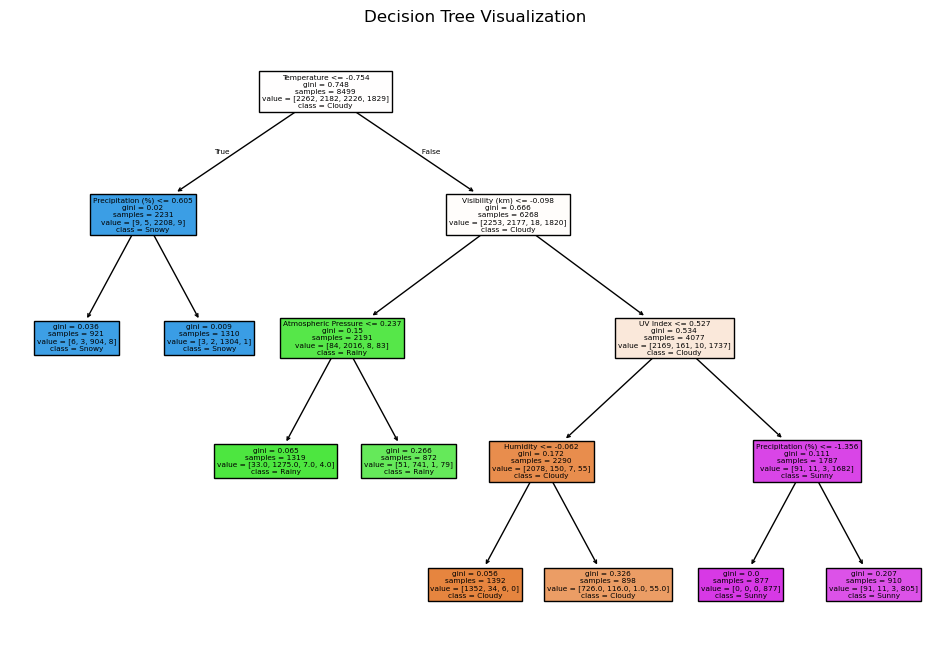

In [84]:
plt.figure(figsize=(12, 8))
plot_tree(Decision_tree_classifier, feature_names=data.drop('Weather Type', axis=1).columns, class_names=LE.classes_, filled=True)
plt.title('Decision Tree Visualization')
# plt.legend()
plt.show()

# Models Testing (Predict new Input Data)

In [85]:
# Mapping of encoded labels to original weather types
label_mapping = {0: 'Cloudy', 1: 'Rainy', 2: 'Snowy', 3: 'Sunny'}

In [86]:
# Function to predict and reverse encode the weather type
def predict_weather(features, models):
    """
    Predicts weather type using the given models and features.
    
    Parameters:
        features (list): A list of feature values for prediction.
        models (dict): A dictionary of trained models (keys are model names, values are model objects).
        
    Returns:
        dict: A dictionary with model names as keys and predicted weather types as values.
    """
    # Preprocess the input features (e.g., scaling)
    features_scaled = scaler.transform([features])  # Ensure features are in a 2D array format
    
    predictions = {}
    for model_name, model in models.items():
        # Predict using the model
        encoded_prediction = model.predict(features_scaled)[0]  # Get the first prediction (single input)
        
        # Decode the prediction
        decoded_prediction = label_mapping[encoded_prediction]
        predictions[model_name] = decoded_prediction
    
    return predictions

In [87]:
models = {
    "KNN": knn,
    "Naive Bayes": nb,
    "SVM": svm_classifier,
    "Decision Tree": Decision_tree_classifier
}

# New input values for prediction
new_features = [25.0, 80, 12.0, 60.0, 2, 1015.0, 5, 2, 7.0, 0]

# Get predictions
predicted_weather = predict_weather(new_features, models)
print("Predicted Weather Types:")
print(predicted_weather)

Predicted Weather Types:
{'KNN': 'Cloudy', 'Naive Bayes': 'Cloudy', 'SVM': 'Cloudy', 'Decision Tree': 'Sunny'}


C:\Users\Mostafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Comparative Analysis Between All **Four Models**

In [88]:
results = {
    "Model": ["KNN", "Naive Bayes", "SVM", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt)
    ]
}

In [89]:
results_df = pd.DataFrame(results)
print("\nComparative Analysis:\n")
print(results_df)


Comparative Analysis:

           Model  Accuracy
0            KNN  0.972706
1    Naive Bayes  0.965647
2            SVM  0.977882
3  Decision Tree  0.937882


### Mased on the **Models Results**
#### Which is all pretty good **The Best Model** for our data is the **Support Vector Machine** with accuracy **Over 97.7%** 

## **Thank You**